In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/tesla_trip_data.csv")

df.head()

,trip_id,speed_mph,outside_temp_f,hvac_on,elevation_gain_ft,distance_miles,energy_used_kwh,wh_per_mile
0,1,35,70,0,120,25,6.2,248
1,2,45,72,0,210,31,8.1,261
2,3,55,68,1,320,38,10.4,274
3,4,65,75,1,500,45,14.2,315
4,5,75,80,1,800,50,18.5,370


In [5]:
X = df[[
    "speed_mph",
    "outside_temp_f",
    "elevation_gain_ft",
    "hvac_on"
]]

In [7]:
y = df["wh_per_mile"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
predictions = model.predict(X_test)

print(predictions)

[309.01577862 235.46759295]


In [15]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(results)

   Actual   Predicted
8     311  309.015779
1     261  235.467593


In [20]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 13.75831421233687


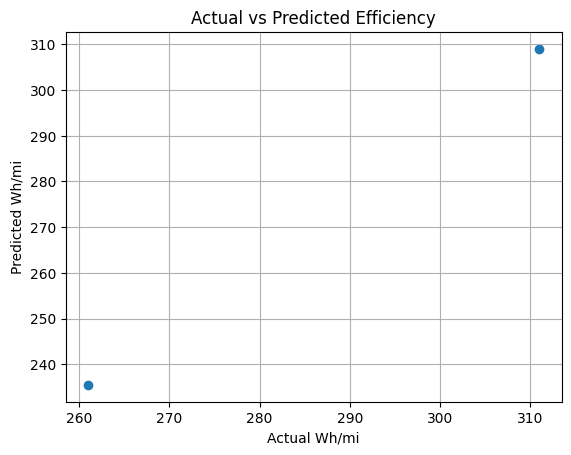

In [21]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Wh/mi")
plt.ylabel("Predicted Wh/mi")
plt.title("Actual vs Predicted Efficiency")

plt.grid(True)
plt.show()